# <font color='blue'> Used Car Price Prediction </font>

The dataset for this study was downloaded from **Kaggle** ([link](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho/data))

## <font color='purple'> Description of Dataset </font>

This dataset contains information about used cars.
This data can be used for a lot of purposes such as price prediction to exemplify the use of linear regression in Machine Learning.

### <font color='blue'> Data Columns </font>

- name
- year
- selling_price
- km_driven
- fuel
- seller_type
- transmission
- Owner

## <font color='orange'> Loading Dataset and Preprocessing </font>

In [7]:
# loading data
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_csv('../data/used_cars.xls')

# Display the first few rows
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [8]:
# check for null entries

null_columns = df.isnull().sum()
print(null_columns)

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [16]:
# data summary

df.describe()

<StringArray>
[                               'Maruti 800 AC',
                     'Maruti Wagon R LXI Minor',
                         'Hyundai Verna 1.6 SX',
                       'Datsun RediGO T Option',
                        'Honda Amaze VX i-DTEC',
                         'Maruti Alto LX BSIII',
                    'Hyundai Xcent 1.2 Kappa S',
                     'Tata Indigo Grand Petrol',
                     'Hyundai Creta 1.6 VTVT S',
                     'Maruti Celerio Green VXI',
 ...
                    'Honda Amaze S Petrol BSIV',
         'Hyundai Santro Xing XS eRLX Euro III',
                            'Hyundai Santro AT',
           'Ford Endeavour 2.2 Titanium AT 4X2',
                   'Chevrolet Spark 1.0 LT BS3',
                             'Maruti Swift LDI',
                                 'Tata Nano XM',
                 'Mahindra Verito 1.5 D6 BSIII',
 'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV',
                   'Hyundai i20 Magna 1.4 CRDi']
L

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


## <font color='orange'> Distribution of Variables </font>

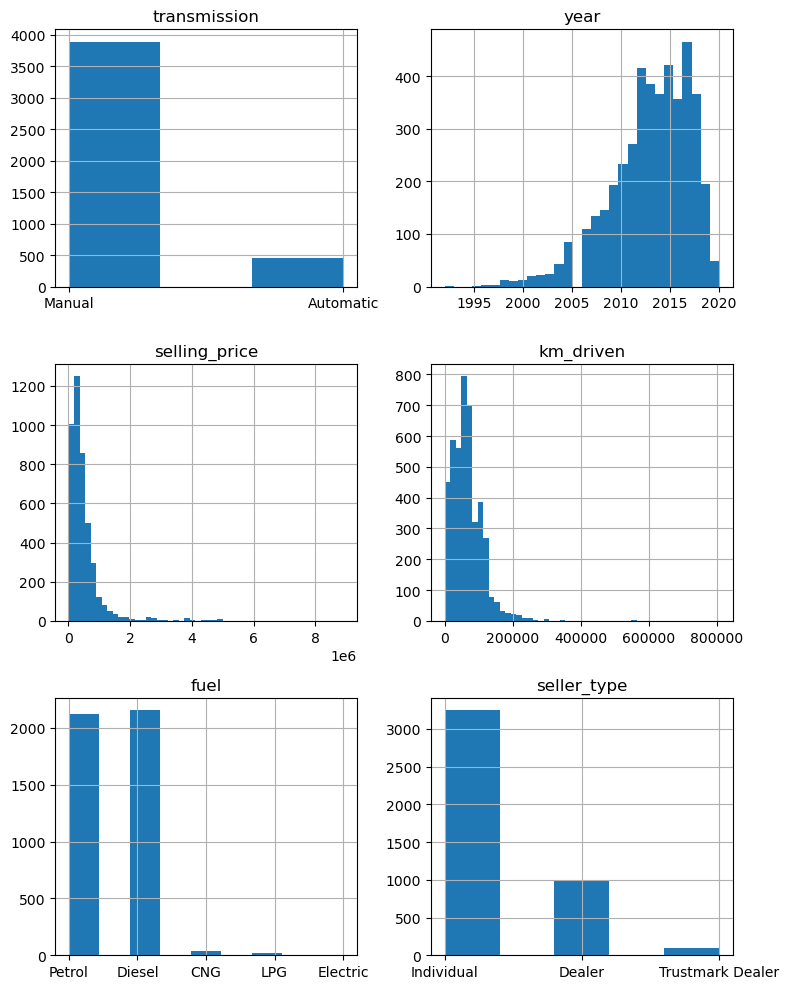

In [28]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 10))
 	 	 	 	 	 	 	 	 	

df['transmission'].hist(bins=3, ax=axes[0,0])
axes[0,0].set_title('transmission')


df['year'].hist(bins=30, ax=axes[0,1])
axes[0,1].set_title('year')


df['selling_price'].hist(bins=50, ax=axes[1,0])
axes[1,0].set_title('selling_price')


df['km_driven'].hist(bins=50, ax=axes[1,1])
axes[1,1].set_title('km_driven')


df['fuel'].hist(bins=9, ax=axes[2,0])
axes[2,0].set_title('fuel')


df['seller_type'].hist(bins=5, ax=axes[2,1])
axes[2,1].set_title('seller_type')


 	 	
plt.tight_layout()
plt.savefig("../figures/variable_distributions.png")
plt.show()

## <font color='orange'> Car Price vs Variables </font>

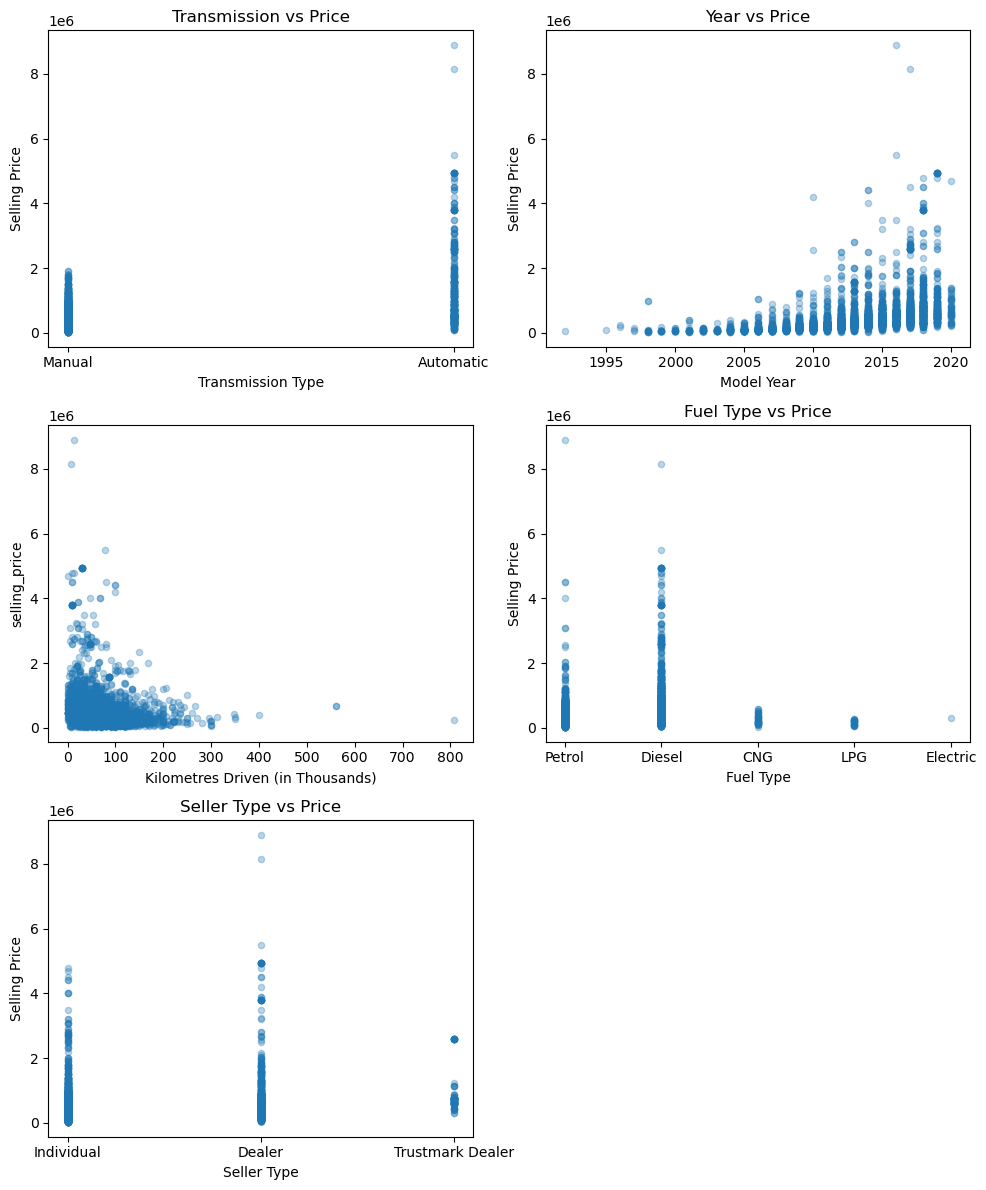

In [30]:
# Create a 3x2 grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 12))

# 1. Transmission vs Selling Price
df.plot(kind='scatter', x='transmission', y='selling_price', ax=axes[0,0], alpha=0.3)
axes[0,0].set_xlabel('Transmission Type')
axes[0,0].set_ylabel('Selling Price')
axes[0,0].set_title('Transmission vs Price')

# 2. Year vs Selling Price
df.plot(kind='scatter', x='year', y='selling_price', ax=axes[0,1], alpha=0.3)
axes[0,1].set_xlabel('Model Year')
axes[0,1].set_ylabel('Selling Price')
axes[0,1].set_title('Year vs Price')

# 3. Kilometres Driven vs Selling Price
df.assign(km_in_thousands = df['km_driven'] / 1000).plot(
    kind='scatter', x='km_in_thousands', y='selling_price', ax=axes[1,0], alpha=0.3
)
axes[1,0].set_xlabel('Kilometres Driven (in Thousands)')

# 4. Fuel Type vs Selling Price
df.plot(kind='scatter', x='fuel', y='selling_price', ax=axes[1,1], alpha=0.3)
axes[1,1].set_xlabel('Fuel Type')
axes[1,1].set_ylabel('Selling Price')
axes[1,1].set_title('Fuel Type vs Price')

# 5. Seller Type vs Selling Price
df.plot(kind='scatter', x='seller_type', y='selling_price', ax=axes[2,0], alpha=0.3)
axes[2,0].set_xlabel('Seller Type')
axes[2,0].set_ylabel('Selling Price')
axes[2,0].set_title('Seller Type vs Price')

# 6. Delete the empty 6th subplot so it doesn't show as a blank box
fig.delaxes(axes[2,1])

# Save and show the visualization
plt.tight_layout()
plt.savefig("../figures/car_price_vs_variables.png")
plt.show()

# <font color='orange'> Corrrelation Heatmap </font>

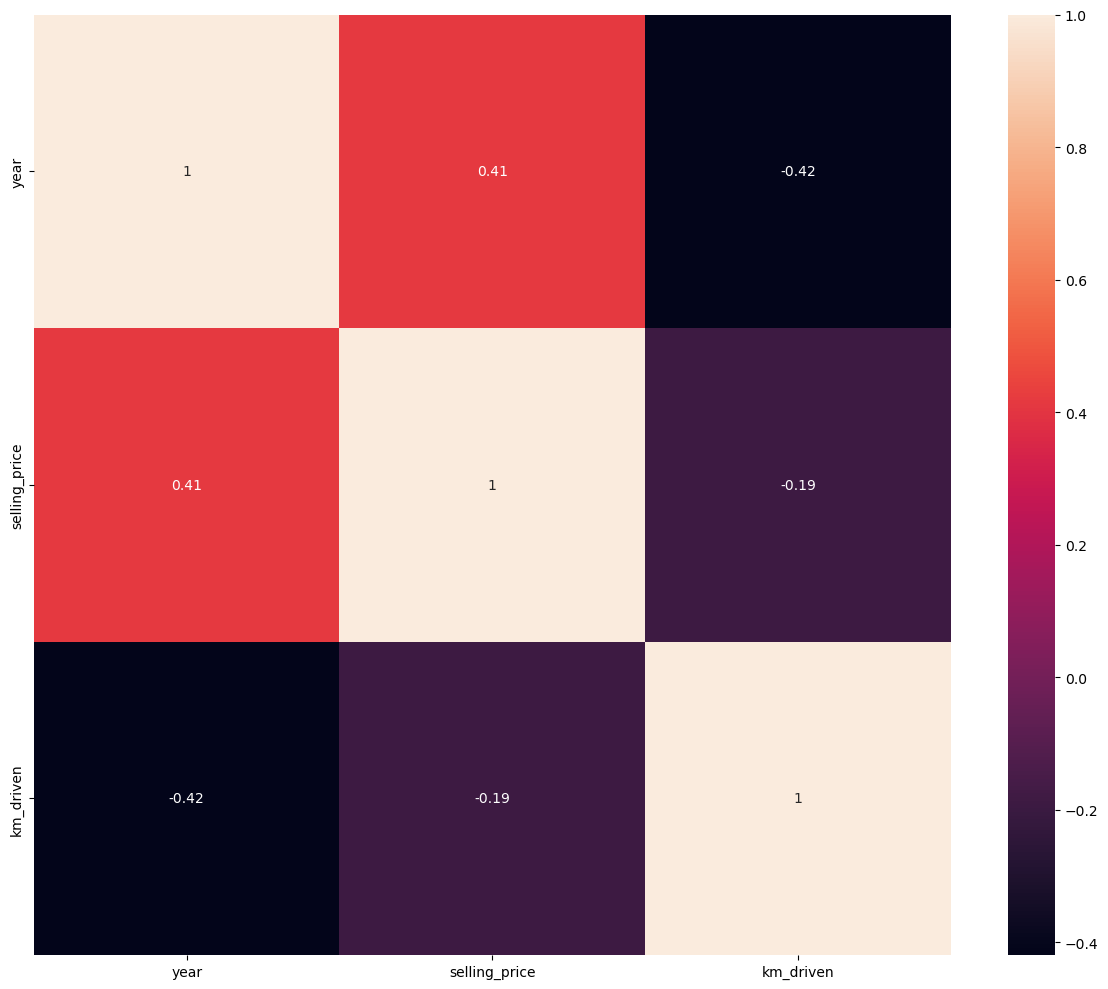

In [33]:
import seaborn as sns

corr_df = df.drop(['name', 'fuel', 'seller_type', 'transmission', 'owner'],  axis='columns')
corr = corr_df.corr(method='pearson')

plt.figure(figsize=(12, 10))

ax = sns.heatmap(corr, annot=True)
plt.tight_layout()
plt.savefig("../figures/variable_correlations.png")
plt.show()